In [1]:
def shift_abc(abc, k):
  return abc[k:] + abc[:k]

def ceasar(text, k):
  abc = "абвгдежзийклмнопрстуфхцъчшыьщэюя"
  abc_shifted = shift_abc(abc, k)
  table = str.maketrans({x:y for (x, y) in zip(abc, abc_shifted)})
  return text.translate(table)

def viginer(text, password):
  abc = "абвгдежзийклмнопрстуфхцъчшыьщэюя"
  n = len(password)
  cipher_text = list(text)
  for i in range(n):
    cipher_text[i::n] = ceasar(text[i::n], password[i])
    # print(cipher_text)
  cipher_text = "".join(cipher_text)
  return cipher_text

def decrypt_ceasar(cipher_text, k):
  abc = "abcdefghijklmnopqrstuvwxyz"
  abc_shifted = shift_abc(abc, k)
  table_inverse = str.maketrans({x:y for (x, y) in zip(abc_shifted, abc)})
  return cipher_text.translate(table_inverse)

password = [1, 2, 3]
text = "приветмир"
cipher_text = viginer(text, password)
text
cipher_text

'ртлгзхнку'

<BarContainer object of 26 artists>

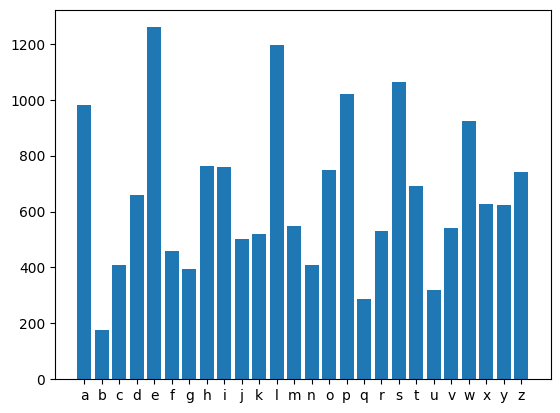

In [2]:
filename = "cipher.txt"
with open(filename) as f:
  text = f.read()

import re
clean_text = re.sub(r"[^a-z]", "", text.lower())

abc = "abcdefghijklmnopqrstuvwxyz"

import matplotlib.pyplot as plt

statistics = {letter: 0 for letter in abc}
for letter in abc:
  statistics[letter] = clean_text.count(letter)

plt.bar(statistics.keys(), statistics.values())


In [3]:
clean_text[:200]

'wfcehcqvycefscprrmnxlcyxajeogejxmyidzfwgmymzfsylsyeneenfqymnsanhhjpjnieftlctxysxqanvgjolhauxgtmehajaeidcazmgzfjehercprrslwumhlswfgbxpwerifvvehehzwpwpeuledhftymulgbwpipgguwtdtahgmeyzlzagvhpypwgcprrmotx'

<BarContainer object of 25 artists>

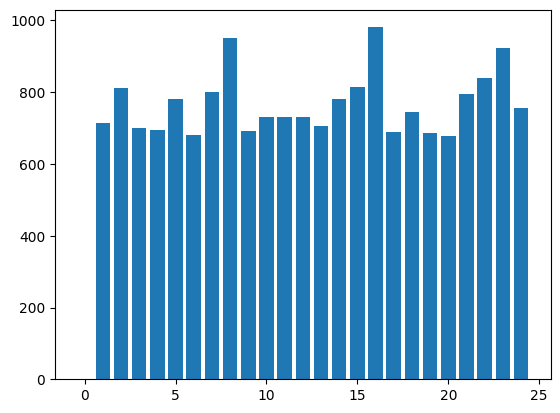

In [4]:
def compute_correlation(cipher_text):
  counts = []
  for k in range(256): # len(password)
    count = 0
    for a, b in zip(cipher_text[:-k], cipher_text[k:]):
      if a == b:
        count += 1
    counts.append(count)
  return counts

counts = compute_correlation(clean_text)

plt.bar(range(25), counts[:25])

In [5]:
m = 8
tracks = [clean_text[i::m] for i in range(m)]
password = []

freq_eng = [
    0.08167, 0.01492, 0.02782, 0.04253, 0.12702, 0.02228,
    0.02015, 0.06094, 0.06966, 0.00153, 0.00772, 0.04025,
    0.02406, 0.06749, 0.07507, 0.01929, 0.00095, 0.05987,
    0.06327, 0.09056, 0.02758, 0.00978, 0.02360, 0.00150,
    0.01974, 0.00074
]

def compute_frequencies(track):
    abc = "abcdefghijklmnopqrstuvwxyz"
    freq = [0] * len(abc)
    total = len(track)

    for letter in track:
        idx = abc.index(letter)
        freq[idx] += 1

    # нормализуем
    freq = [x / total for x in freq]
    return freq


for track in tracks:
  best_shift = 0
  best_score = -10000
  
  for shift in range(26):
    back_shifted_track = decrypt_ceasar(track, shift)
    freq_track = compute_frequencies(back_shifted_track)
    
    score = 0
    for letter_index in range(26):
      score += freq_track[letter_index] * freq_eng[letter_index]

    if score > best_score:
      best_score = score
      best_shift = shift
  
  password.append(best_shift)

password

[11, 11, 11, 11, 0, 0, 11, 11]

In [6]:
text = list(clean_text)
for i in range(m):
  text[i::m] = decrypt_ceasar(clean_text[i::m], password[i])
text = "".join(text)
text


'lurthcfknrtusceggbcmlcnmpytdgeymbnxszflvbnbofsnahntceecufnbcsacwwyeynituiarixyhmfpckgjdawpjmgtbtwpypeisrpobvzfytwtgrprghaljbhlhluvqmpwtgxukkehtwolelpejatswutybjavqlpievvjlidtpwvbtnzlopvkweyplvreggmoimowmiaueloaevpstgeaadadxhpxrpjhpwpuitrxwmansnsggyrecnlmkiesahlhmoehledaaetxxxpelsdstkhwtoglzlietttcrwroaalfwxeykmvxniwdealhtmablgrepeytohdjmoehpyprxanzaaganscsaohmehkgramsydqghjlcrtshvsgtopssvzxnbpoiwgdcdyrwymedisiesbthetiualofqppdsbremrehdinvobxmxrecevgtuinpebgulofhhbljaestgzlviehzkwhvalapeeoyeltvvqpogtewpbjprtymckpeavplxnehwlmpdtoyeklweikeophomhltlubhusralpomancawllxndskgppltemlxywmurewvpaertoysplofbughhvulppmvjlwegarpmhehlqwwlthtdxmbythpegsixouizjldxcignyapbuitmohlalacbyomacopolrthtmnsiwwegpbuziritdhhpsaaqsemehprdknlogwhvkhozozhvsveruiyamtyexdwlgrtwxbhaslymzxinisxkfltebdhambshdcmwktnyisbfnthtqnzlaouaousvandhbowheowlolwjfsteahpalslptravehpymoajfsttgadisojdxohtxpoxtuhhyuflloujepvbucmtyuzbswgohgliwegrtilkvqgolczekxncyihbpyudetjnhssmuyboxihaztmeoelwxaxnlbdsodxnmnqykaulelmzleoasqkgtmheicbure

In [8]:
output_filename = "cracked.txt"
with open(output_filename, "w") as f:
  f.write(text)